# Data Augmentation for Improved Forecasting Accuracy

Global forecasting models share parameters across series. Extra training series can help when the original sample is small. Offline augmentation generates those series before fitting: transform the training set, concatenate, then train as usual.

This notebook follows the **NeuralForecast** workflow from [Nixtla](https://github.com/Nixtla/neuralforecast). Data is a long DataFrame with `unique_id`, `ds`, and `y`. NHITS is trained with `NeuralForecast.fit` / `predict`. A transformer from `metaforecast.synth` builds the extra series.

The steps are as follows.

1. Load M3 monthly and split each series into train and a 12-month test window.
2. Generate synthetic series with SeasonalMBB and concatenate them to the training set.
3. Fit two NHITS models: one on the original training data, one on the augmented set.
4. Rank NHITS and NHITS(MBB) by test SMAPE.

SeasonalMBB is the worked example. A catalog of all 18 generators, with one plot each, is in the generators notebook. Online augmentation during training is in the next notebook.


In [1]:
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

If necessary, install the package using pip:


In [2]:
# !pip install metaforecast

## 1. Data preparation

This tutorial uses the M3 monthly dataset from `datasetsforecast`. Horizon and input size (lags) are both 12 months.

`SeriesWiseSplit.time_wise_split` keeps the last `horizon` observations of each series as the test set.


In [3]:
import pandas as pd
from datasetsforecast.m3 import M3

from metaforecast.evaluation.cv import SeriesWiseSplit

horizon = 12
n_lags = 12

df, *_ = M3.load(".", group="Monthly")
train_df, test_df = SeriesWiseSplit.time_wise_split(df, horizon=horizon)

print(train_df["unique_id"].nunique(), "series")
train_df.head()

1428 series


,unique_id,ds,y
0,M1,1990-01-31,2640.0
1,M1,1990-02-28,2640.0
2,M1,1990-03-31,2160.0
3,M1,1990-04-30,4200.0
4,M1,1990-05-31,3360.0


Sanity-check the split on series `M1000`. Training should end where the test window begins.


In [4]:
train_df.query('unique_id=="M1000"').tail()

,unique_id,ds,y
286,M1000,1992-10-31,4563.399902
287,M1000,1992-11-30,4551.799805
288,M1000,1992-12-31,4577.399902
289,M1000,1993-01-31,4592.399902
290,M1000,1993-02-28,4632.200195


In [5]:
test_df.query('unique_id=="M1000"').head()

,unique_id,ds,y
36,M1000,1993-03-31,4625.600098
37,M1000,1993-04-30,4668.200195
38,M1000,1993-05-31,4598.000000
39,M1000,1993-06-30,4619.399902
40,M1000,1993-07-31,4640.399902


## 2. Data augmentation

SeasonalMBB is a seasonal moving-block bootstrap: it decomposes each series with STL, resamples residual blocks of length `seas_period` (12 on monthly M3), and rebuilds the series so trend and seasonality stay put. `transform` takes the training frame and returns one synthetic copy per series, with new identifiers such as `M1_MBB0`. Concatenate that copy with `train_df` to form the augmented training set.


In [6]:
from metaforecast.synth import SeasonalMBB

tsgen = SeasonalMBB(seas_period=12)
synth_df = tsgen.transform(train_df)

In [7]:
synth_df.head()

,unique_id,ds,y
0,M1_MBB0,1990-01-31,1702.335331
1,M1_MBB0,1990-02-28,2958.288852
2,M1_MBB0,1990-03-31,3308.886470
3,M1_MBB0,1990-04-30,3253.486526
4,M1_MBB0,1990-05-31,2204.955690


In [8]:
train_aug = pd.concat([train_df, synth_df])

pd.DataFrame(
    {
        "n_series": [
            train_df["unique_id"].nunique(),
            synth_df["unique_id"].nunique(),
            train_aug["unique_id"].nunique(),
        ]
    },
    index=["original", "synthetic", "augmented"],
)

,n_series
original,1428
synthetic,1428
augmented,2856


Plot one original series against its SeasonalMBB copy. The synthetic series keeps the seasonal shape; the residual path is what changes.


Text(0.5, 1.0, 'M1: original vs synthetic')

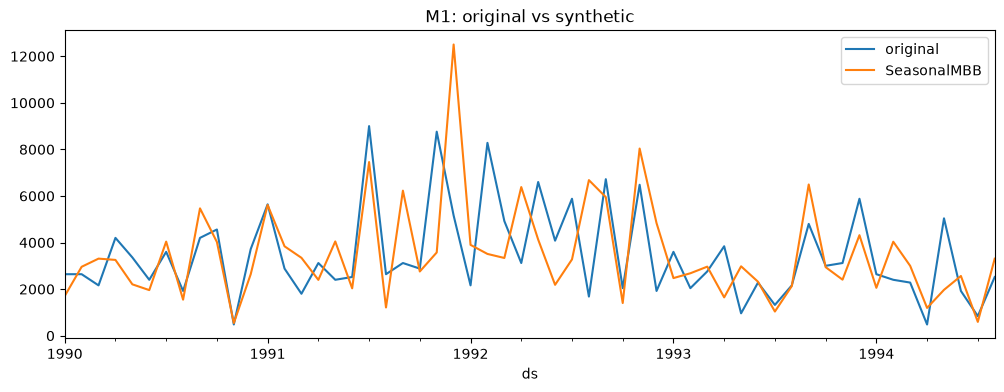

In [9]:
uid = "M1"
synth_uid = synth_df.loc[
    synth_df["unique_id"].str.startswith(f"{uid}_{tsgen.alias}"),
    "unique_id",
].iloc[0]
obs = train_df.query("unique_id == @uid").set_index("ds")["y"]
synth = synth_df.query("unique_id == @synth_uid").set_index("ds")["y"]

ax = obs.plot(figsize=(12, 4), label="original")
synth.plot(ax=ax, label="SeasonalMBB")
ax.legend()
ax.set_title(f"{uid}: original vs synthetic")


## 3. Model setup and fitting

NHITS uses a small CPU config (`max_steps=1000`). Progress bars and Lightning logs are turned off.

The two wrappers must not share a model object: each `NeuralForecast` instance gets its own `NHITS`. Fit one on `train_df` and one on `train_aug`. Predict both on the original series so the test comparison is fair.


In [10]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

CONFIG = {
    "max_steps": 1000,
    "input_size": n_lags,
    "h": horizon,
    "accelerator": "cpu",
    "enable_progress_bar": False,
    "enable_model_summary": False,
    "logger": False,
}

nf_og = NeuralForecast(
    models=[NHITS(start_padding_enabled=True, **CONFIG)],
    freq="ME",
)
nf_aug = NeuralForecast(
    models=[NHITS(start_padding_enabled=True, **CONFIG)],
    freq="ME",
)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


In [11]:
%%capture

nf_og.fit(df=train_df)
nf_aug.fit(df=train_aug)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [12]:
fcst_og = nf_og.predict(df=train_df)
fcst_aug = nf_aug.predict(df=train_df)

fcst_og = fcst_og.drop(columns=["cutoff"], errors="ignore")
fcst_aug = fcst_aug.drop(columns=["cutoff"], errors="ignore")

fcst = fcst_aug.rename(columns={"NHITS": "NHITS(MBB)"}).merge(
    fcst_og, on=["unique_id", "ds"]
)

fcst.head()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


,unique_id,ds,NHITS(MBB),NHITS
0,M1,1994-09-30,2772.359863,2961.115234
1,M1,1994-10-31,2345.917236,2942.299805
2,M1,1994-11-30,2529.728760,3092.578369
3,M1,1994-12-31,3011.731689,2732.066406
4,M1,1995-01-31,2046.548218,2267.695801


## 4. Evaluation

SMAPE on the 12-month test window, averaged over series. Lower is better.


In [13]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import smape

models = [c for c in fcst.columns if c not in ("unique_id", "ds")]
test_eval = test_df.merge(fcst, on=["unique_id", "ds"], how="left")
evaluation_df = evaluate(df=test_eval, metrics=[smape], models=models)
evaluation_df.head()

,unique_id,metric,NHITS(MBB),NHITS
0,M1,smape,0.291610,0.310770
1,M10,smape,0.091351,0.097461
2,M100,smape,0.044235,0.048009
3,M1000,smape,0.002744,0.006850
4,M1001,smape,0.009100,0.010249


In [ ]:
mean_smape = evaluation_df.drop(columns=["metric", "unique_id"]).mean().sort_values()
mean_smape

NHITS(MBB)    0.063806
NHITS         0.064163
dtype: float64